In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets
from torchvision import transforms

from torch.utils.data import Subset

def count_trainable_params(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

def build_mnist_subset(
    classes,
    train=True
):

    ds = datasets.MNIST(
        root="./data",
        train=train,
        download=False,
        transform=transforms.ToTensor()
    )

    idx = []

    for i, (_, y) in enumerate(ds):

        if y in classes:
            idx.append(i)

    return Subset(ds, idx)

In [3]:
base_classes = [0, 1, 2, 3, 4, 5, 6, 7]

input_dim = 784
hidden1 = 32
hidden2 = 16

epochs = 10
batch_size = 256
learning_rate = 0.001

In [4]:
DEVICE = ("cuda" if torch.cuda.is_available() else "cpu")

train_ds = build_mnist_subset(base_classes, train=True)
test_ds = build_mnist_subset(base_classes, train=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

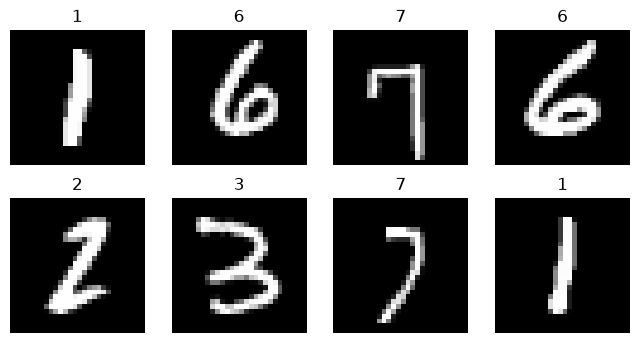

In [5]:
figure = plt.figure(figsize=(8, 4))
cols, rows = 4, 2

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_ds), size=(1,)).item()
    img, label = train_ds[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [6]:
class BackboneMLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, num_classes=8):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)

        self.relu = nn.ReLU()

        self.classifier = nn.Linear(
            hidden2,
            num_classes
        )

    def forward_features(self, x):

        x = x.view(x.size(0), -1)

        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))

        return h2

    def forward(self, x):

        h = self.forward_features(x)
        return self.classifier(h)


In [7]:
model = BackboneMLP(
    hidden1=hidden1,
    hidden2=hidden2,
    num_classes=len(base_classes)
).to(DEVICE)

opt = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

criterion = torch.nn.CrossEntropyLoss()
print(f"Trainable parameters: {count_trainable_params(model)}")

Trainable parameters: 25784


In [8]:
for epoch in range(epochs):
    model.train()

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad()
        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()
        opt.step()

    print(
        f"epoch={epoch+1} "
        f"loss={loss.item():.4f}"
    )

epoch=1 loss=0.2381
epoch=2 loss=0.0458
epoch=3 loss=0.0729
epoch=4 loss=0.1262
epoch=5 loss=0.0246
epoch=6 loss=0.0426
epoch=7 loss=0.0403
epoch=8 loss=0.0517
epoch=9 loss=0.1300
epoch=10 loss=0.0667


In [9]:
with torch.no_grad():
    total = 0
    correct = 0
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    # Calculate the overall accuracy
    accuracy = correct / total
    print(f"accuracy = {accuracy:.3f}, total = {total}, correct = {correct}")

accuracy = 0.974, total = 8017, correct = 7806


In [60]:
torch.save(
    model.state_dict(),
    "checkpoints/pretrained.pt"
)

### Fine tune the last layer of the model

In [10]:
target_classes = [8, 9]
class_offset = min(target_classes)

train_ds = build_mnist_subset(target_classes, train=True)
test_ds = build_mnist_subset(target_classes, train=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

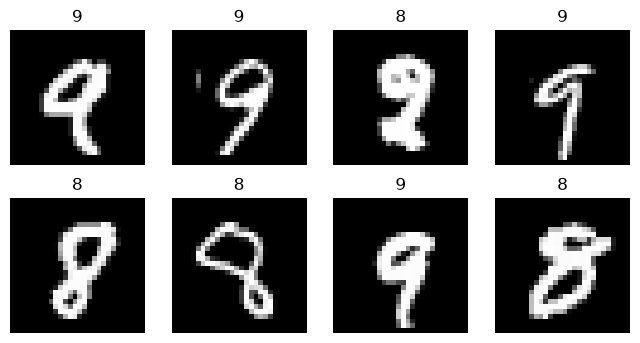

In [11]:
figure = plt.figure(figsize=(8, 4))
cols, rows = 4, 2

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_ds), size=(1,)).item()
    img, label = train_ds[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [17]:
# Freeze entire backbone
for p in model.fc1.parameters():
    p.requires_grad = False

for p in model.fc2.parameters():
    p.requires_grad = False


# Replace classifier
model.classifier = nn.Linear(hidden2, len(target_classes))

for p in model.classifier.parameters():
    p.requires_grad = True

model = model.to(DEVICE)

print(f"Trainable params: {count_trainable_params(model):,}")


opt = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=learning_rate
)

criterion = nn.CrossEntropyLoss()

Trainable params: 34


In [45]:
model.classifier.weight.shape

torch.Size([2, 16])

In [23]:
with torch.no_grad():
    total = 0
    correct = 0
    for x, y in test_loader:
        y = (y - class_offset).long()
        x, y = x.to(DEVICE), y.to(DEVICE)
        outputs = model(x)
        
        loss = criterion(outputs, y)

        # Calculate accuracy
        _, pred = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    # Calculate the overall accuracy
    accuracy = correct / total
    print(f"accuracy = {accuracy:.3f}, total = {total}, correct = {correct}")

accuracy = 0.921, total = 1983, correct = 1827


In [22]:
for epoch in range(4):
    model.train()

    for x, y in train_loader:
        y = (y - class_offset).long()
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        opt.zero_grad()
        logits = model(x)

        loss = criterion(logits, y)

        loss.backward()
        opt.step()

    print(
        f"epoch={epoch+1} "
        f"loss={loss.item():.4f}"
    )

epoch=1 loss=0.5036
epoch=2 loss=0.6014
epoch=3 loss=0.2134
epoch=4 loss=0.3235


In [49]:
with torch.no_grad():
    total = 0
    correct = 0
    for x, y in test_loader:
        y = (y - class_offset).long()
        x, y = x.to(DEVICE), y.to(DEVICE)
        outputs = model(x)

        # Calculate accuracy
        _, pred = torch.max(outputs.data, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    # Calculate the overall accuracy
    accuracy = correct / total
    print(f"accuracy = {accuracy:.3f}, total = {total}, correct = {correct}")

accuracy = 0.953, total = 1983, correct = 1890


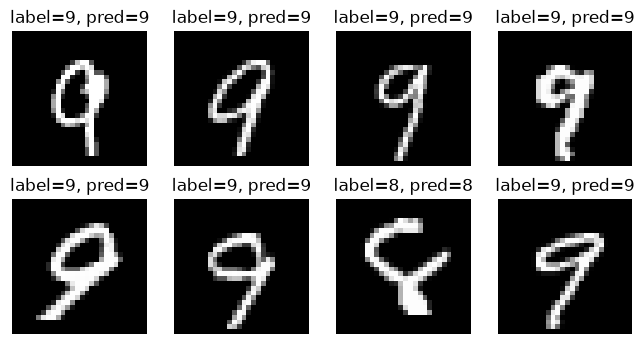

In [50]:
figure = plt.figure(figsize=(8, 4))
cols, rows = 4, 2

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_ds), size=(1,)).item()
    img, label = train_ds[sample_idx]
    figure.add_subplot(rows, cols, i)
    _, pred = torch.max(model(img).data, 1)
    pred = pred.item() + class_offset
    plt.title(f"label={label}, pred={pred}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [52]:
torch.save(
    model.state_dict(),
    "checkpoints/finetuned.pt"
)